In [1]:
import os
os.environ["JAX_PLATFORM_NAME"] = "cpu"
os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=12"

import sys
sys.path.append('../../src/')

import numpy as onp
import jax
import jax.numpy as jnp

from myutils_corrected import Ntime, ACFs, set_detectors, set_detector_locations, load_tables, cov_resp, initialize_det_locs
from myutils_corrected import ln_likelihood_full_jit, ln_likelihood_full
from other_utils import calculate_SNR

from scipy.linalg import toeplitz, solve_triangular

import lal

jax.config.update("jax_enable_x64", True) 

/Users/kallol/Work/skyRing/examples/simulations_220_221/../../src/myutils_corrected.py:3: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from chainconsumer import Chain, ChainConsumer, Truth, ChainConfig, PlotConfig

import numpyro
from numpyro.contrib.nested_sampling import NestedSampler
import numpyro.distributions as dist
numpyro.enable_x64()

/Users/kallol/miniconda3/envs/skyloc_ringdown/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Likelihood extras
factor     = 10

seed       = 31567 
T          = 0.1
srate      = 4096 
t0         = 0.0
fmin       = 30
fmax       = 1500


tgps       = 1420878141.2379541 



psdH_path  = "../../data/PSDs/PSD_H1_GW250114.txt"
psdL_path  = "../../data/PSDs/PSD_L1_GW250114.txt"
qnm1_path  = "../../data/l2/n1l2m2.dat"
qnm2_path  = "../../data/l2/n2l2m2.dat"

In [4]:
# Prior limits
limits = [
    [30.0, 95.0],
    [0., 0.99],
    [0., 8.0],
    [0., 6.283185307179586],
    [0., 8.0],
    [0., 6.283185307179586],
    [-1., 1.],
    [0, 6.28],
    [-1., 1.],
    [0, 3.14]]

low  = onp.asarray([pair[0] for pair in limits], dtype=onp.float64)
high = onp.asarray([pair[1] for pair in limits], dtype=onp.float64)

Load PSDs, and interpolate 22, 33 mode frequency as a function of mass and spin (from Berti fits). Also initiate detector location for likelihood

In [5]:
psdH, psdL, omega_r, omega_i, omega_OT_r, omega_OT_i = load_tables(psdH_path, psdL_path, qnm1_path, qnm2_path)
tgps = lal.LIGOTimeGPS(tgps)
gmst = lal.GreenwichMeanSiderealTime(tgps)

L_H, L_L, resp_H, resp_L = cov_resp(srate=srate, T=T, psdH=psdH, psdL=psdL, factor=factor)
set_detectors(resp_H, resp_L)

rH, rL = initialize_det_locs()
set_detector_locations(rH, rL)

Load data strain. 'new' corresponds to data for FULL-SKY analysis

In [6]:
# Load data strains
h_H_t = onp.loadtxt('./H1-sim-new.txt')
h_L_t = onp.loadtxt('./L1-sim-new.txt')

Testing likelihood with injection parameters. (Expect to be slightly off since early L1 data is missing!)

In [7]:
M_obs      = 72 
chi_obs    = 0.75 
A220_obs   = 0.5
P220_obs   = 2.2 
A221_obs   = 0.8 
P221_obs   = 4.5 
ra         = 2.33
dec        = 0.19
psi        = 1.329
iota       = 0.65 



theta_GT = jnp.array([M_obs, chi_obs, A220_obs, P220_obs, A221_obs, P221_obs, onp.cos(iota), ra, onp.sin(dec), psi])



print("Test: logL evaluated at GT (TD): ", ln_likelihood_full(
            dataH=h_H_t, dataL=h_L_t, params=theta_GT, gmst=gmst, L_H=L_H, L_L=L_L, 
            omega_r=omega_r, omega_i=omega_i, omega_OT_r=omega_OT_r, omega_OT_i=omega_OT_i, 
            T=T, srate=srate, t0=t0
            )
    )

Test: logL evaluated at GT (TD):  -9.00730555306313


SNR for this signal

In [8]:
snr_H = calculate_SNR(h_H_t, L_H)
snr_L = calculate_SNR(h_L_t, L_L)
print('total SNR : ', onp.sqrt(snr_H**2 + snr_L**2))

total SNR :  22.629665087598287


Set up the numpyro model. Computes likelihood as a function of $\theta$

In [9]:
low  = jnp.asarray(low,  dtype=jnp.float64)   
high = jnp.asarray(high, dtype=jnp.float64)  


def make_loglik_fn(dataH, dataL, gmst, L_H, L_L,
                   omega_r, omega_i, omega_OT_r, omega_OT_i,
                   T, srate, t0):
    def _loglik(theta):
        return ln_likelihood_full_jit(
            dataH=dataH, dataL=dataL, params=theta,
            gmst=gmst, L_H=L_H, L_L=L_L,
            omega_r=omega_r, omega_i=omega_i,
            omega_OT_r=omega_OT_r, omega_OT_i=omega_OT_i,
            T=T, srate=srate, t0=t0
        )
    return _loglik

loglik_fn = make_loglik_fn(
    dataH=h_H_t, dataL=h_L_t,
    gmst=gmst, L_H=L_H, L_L=L_L,
    omega_r=omega_r, omega_i=omega_i,
    omega_OT_r=omega_OT_r, omega_OT_i=omega_OT_i,
    T=T, srate=srate, t0=t0
)

def model():
    theta = numpyro.sample("theta", dist.Uniform(low, high).to_event(1))
    numpyro.factor("loglike", loglik_fn(theta))

In [10]:
rng_key = jax.random.PRNGKey(int(seed) ^ 0xABCDEF)
rng_run, rng_post = jax.random.split(rng_key)
ns = NestedSampler(
    model,
    constructor_kwargs=dict(
        num_live_points=10000,     
        max_samples=500_000,      
        verbose=False,
    ),
    termination_kwargs=dict(
        dlogZ=0.01,               
    ),
)
ns.run(rng_run)
ns.print_summary()
posterior = ns.get_samples(rng_post, num_samples=100_000)

INFO:jaxns:Number of Markov-chains set to: 10000


Running over 12 devices.
--------
Termination Conditions:
Small remaining evidence
--------
likelihood evals: 62806577
samples: 245196
phantom samples: 0
likelihood evals / sample: 256.1
phantom fraction (%): 0.0%
--------
logZ=-25.179 +- 0.055
max(logL)=-0.03
H=-20.87
ESS=26324
--------
theta[#]: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
theta[0]: 71.6 +- 4.3 | 66.0 / 71.6 / 77.2 | 72.0 | 72.0
theta[1]: 0.729 +- 0.067 | 0.641 / 0.737 / 0.81 | 0.751 | 0.751
theta[2]: 2.3 +- 1.6 | 0.8 / 1.8 / 4.7 | 0.7 | 0.7
theta[3]: 3.1 +- 1.8 | 0.8 / 2.9 / 5.7 | 3.2 | 3.2
theta[4]: 3.3 +- 2.1 | 1.1 / 2.8 / 6.9 | 1.2 | 1.2
theta[5]: 3.2 +- 1.7 | 0.9 / 3.4 / 5.4 | 5.5 | 5.5
theta[6]: -0.01 +- 0.41 | -0.59 / 0.02 / 0.51 | -0.39 | -0.39
theta[7]: 3.0 +- 1.3 | 1.3 / 3.0 / 4.7 | 2.7 | 2.7
theta[8]: -0.06 +- 0.58 | -0.95 / 0.06 / 0.67 | 0.57 | 0.57
theta[9]: 1.63 +- 0.89 | 0.29 / 1.73 / 2.87 | 1.69 | 1.69
--------


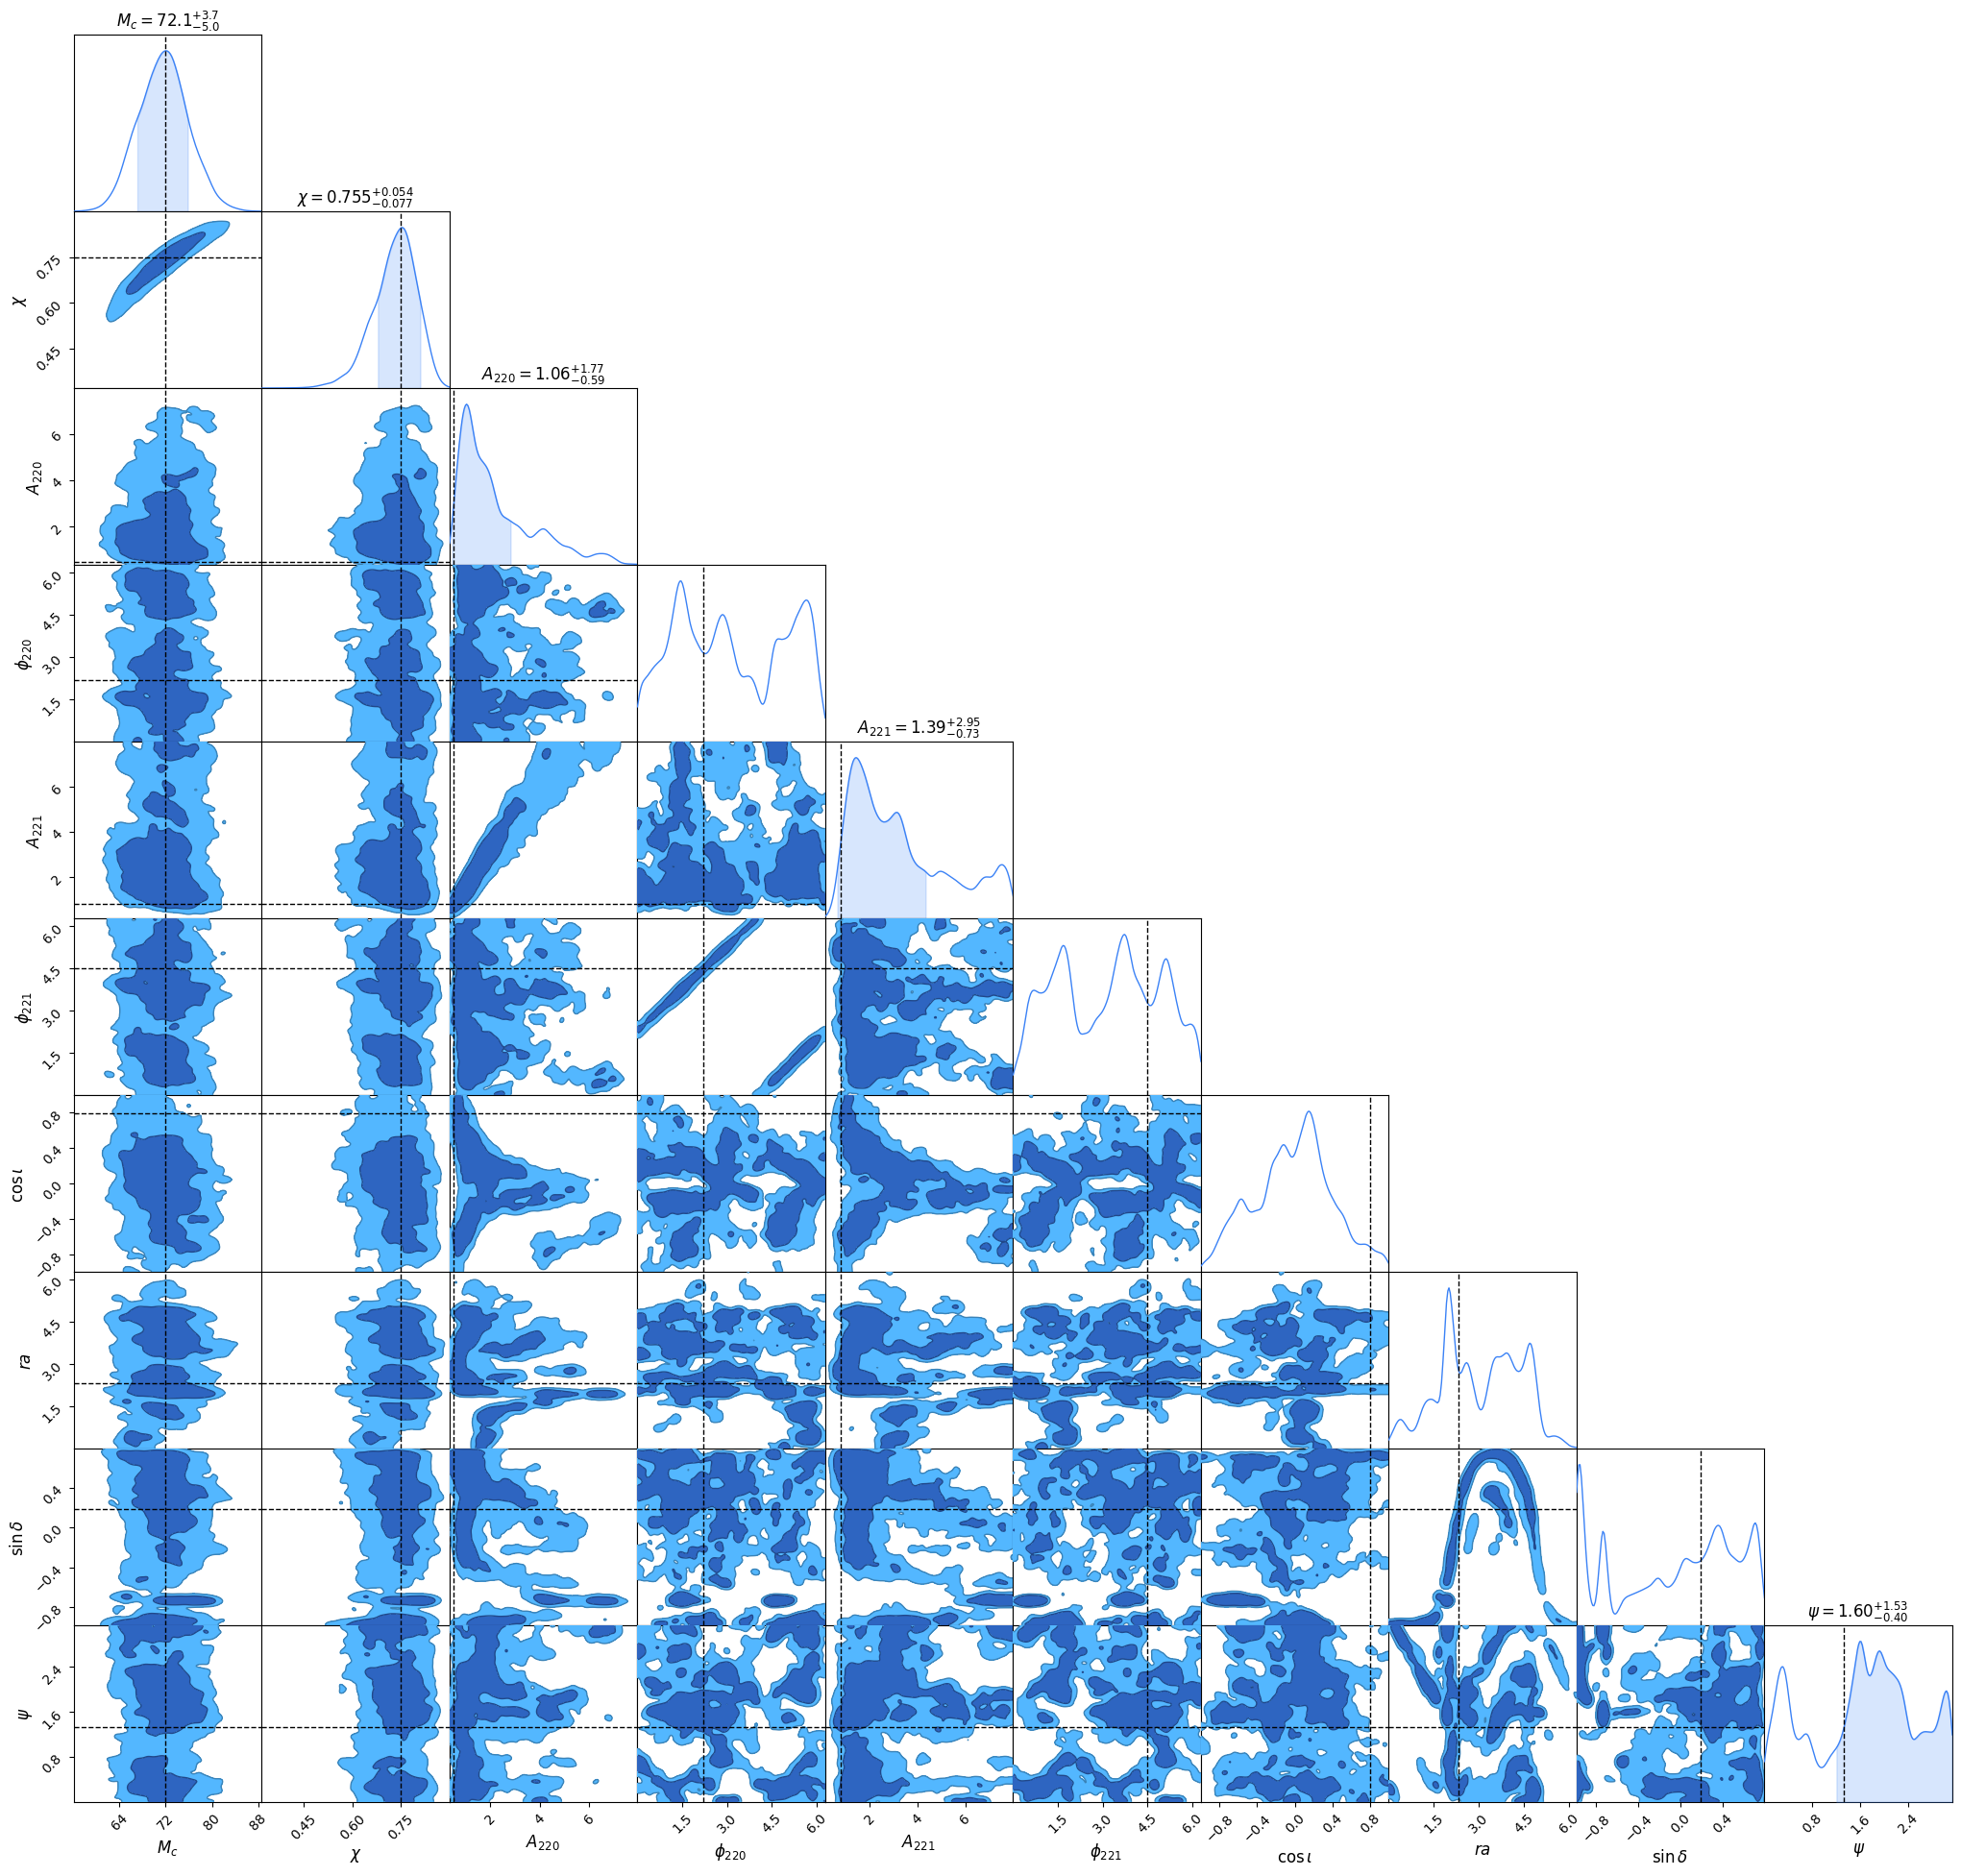

In [11]:
ns_parameters = [r'$M_c$', r'$\chi$', r'$A_{220}$', r'$\phi_{220}$', r'$A_{221}$', r'$\phi_{221}$', r'$\cos\iota$', r'$ra$', r'$\sin \delta$', r'$\psi$']

truths = {}
for i in range(len(ns_parameters)):
    truths[ns_parameters[i]] = theta_GT[i]

df_ns = pd.DataFrame(posterior['theta'], columns=ns_parameters)
c = ChainConsumer()
c.add_chain(Chain(samples=df_ns, color='b', name="Full sky"))
c.set_override(ChainConfig(sigmas=[0, 1, 2]))
c.set_plot_config(
    PlotConfig(
        # flip=True,
        # labels=ns_parameters,
        contour_label_font_size=24,
        legend_kwargs={'fontsize': 30}
    )
)
c.add_truth(Truth(location=truths, color='#000000'))
# c.add_truth(Truth(location={r'$ra$':2.33, r'$\sin \delta$':onp.sin(0.19)}, color='#000000'))
# c.add_truth(Truth(location={r'$ra$':4.5, r'$\sin \delta$':onp.sin(0.45)}, color='#000000'))
fig = c.plotter.plot()
# plt.savefig(corner_path, dpi=300, bbox_inches='tight')
plt.show()

In [13]:
onp.save('posterior.noiseless-sim.full-sky.npy', onp.asarray(posterior['theta']))

In [12]:
posterior_dir = '../posterior_files/simulations_220_221/'
onp.save(posterior_dir + 'posterior.noiseless-sim.full-sky.npy', onp.asarray(posterior['theta']))

In [14]:
theta_GT

Array([72.        ,  0.75      ,  0.5       ,  2.2       ,  0.8       ,
        4.5       ,  0.7960838 ,  2.33      ,  0.18885889,  1.329     ],      dtype=float64)